#LAB 06 -Multi Dimensional Scaling (MDS)#

**NAME : RAKSHITHA V S**<BR>
**ROLL : 2348448**<BR>
**CLASS: 3 MDS B**




* Multidimensional scaling (MDS) is a technique for
visualizing distances between objects, where the
distance is known between pairs of the objects. The
input to multidimensional scaling is a distance matrix.
The output is typically a two-dimensional scatterplot,
where each of the objects is represented as a point.
* MDS is a dimensionality
reduction technique that is used to project
high-dimensional data onto a lower-dimensional space
while preserving the pairwise distances between the
data points as much as possible.



In [1]:
import numpy as np                                            # To manage NumPy arrays
import pandas as pd                                           # To import and print summary stats for data set
from matplotlib import pyplot as plt
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## About the Dataset

- rows 0-9 correspond to Texan cities and rows 10-19 correspond to Californian cities.<br><br>
- The values in the Distances column refer to the Euclidean (straight-line) distance between a city and its state geographical centroid. Therefore, Texan cities have their distance measured to Texas's centroid and Californian cities have their distance measured to California's centroid.<br><br>

In [3]:
df = pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/lab6.csv")
df

,Cities,Distance (km),Population (people),Median Income (USD),Travel to Work (min)
0,Amarillo,477,203245,52543,17.8
1,Austin,202,974581,67462,24.3
2,Corpus Christi,449,326162,55709,19.2
3,Dallas,279,1358066,50100,27.0
4,El Paso,678,681877,45656,22.8
5,Fort Worth,236,894195,59255,27.2
6,Houston,424,2338187,51140,27.4
7,Midland,266,144600,79744,18.8
8,San Antonio,242,1544672,50980,24.4
9,Waco,207,139324,37735,17.5


In [4]:
df.shape

(20, 5)

In [ ]:
df.describe()

,Distance (km),Population (people),Median Income (USD),Travel to Work (min)
count,20.000000,2.000000e+01,20.00000,20.000000
mean,315.300000,9.107892e+05,63680.95000,24.680000
std,142.894551,9.235866e+05,17685.65808,5.068022
min,57.000000,9.136400e+04,37735.00000,17.000000
25%,230.500000,3.443142e+05,51100.00000,21.150000
50%,267.000000,6.067265e+05,58855.50000,24.350000
75%,404.500000,1.105863e+06,70781.75000,27.675000
max,678.000000,3.979576e+06,104552.00000,33.300000


## Standardizing

In [6]:
scaler=StandardScaler()

In [7]:
df[['Distance (km)','Population (people)','Median Income (USD)','Travel to Work (min)']] = scaler.fit_transform(df[['Distance (km)','Population (people)','Median Income (USD)','Travel to Work (min)']])
df

,Cities,Distance (km),Population (people),Median Income (USD),Travel to Work (min)
0,Amarillo,1.161001,-0.785985,-0.646133,-1.392798
1,Austin,-0.813490,0.070864,0.219346,-0.076928
2,Corpus Christi,0.959962,-0.649441,-0.462468,-1.109380
3,Dallas,-0.260633,0.496863,-0.787857,0.469664
4,El Paso,2.604175,-0.254290,-1.045661,-0.380590
5,Fort Worth,-0.569371,-0.018434,-0.256758,0.510153
6,Houston,0.780463,1.585644,-0.727524,0.550641
7,Midland,-0.353972,-0.851131,0.931848,-1.190357
8,San Antonio,-0.526292,0.704157,-0.736806,-0.056684
9,Waco,-0.777591,-0.856992,-1.505173,-1.453531


Our imported data is currently a pandas.DataFrame of dimensions 20x4
.The first step in computing the distance matrix is to convert this dataframe into NumPy format and then apply the Euclidean distance formula to every pair of events. In other words, we want to find every possible distance between two observations in our data set.

First row of D is:
 [0.         2.6670911  0.41607684 2.67499429 1.884048   2.71222398
 3.09079473 2.19781613 2.61933248 2.12245542 2.44984258 2.26310722
 3.15895283 5.09309174 3.5400915  2.39251222 1.78350001 2.33026688
 4.66570584 4.43691984]
First column of D is:
 [0.         2.6670911  0.41607684 2.67499429 1.884048   2.71222398
 3.09079473 2.19781613 2.61933248 2.12245542 2.44984258 2.26310722
 3.15895283 5.09309174 3.5400915  2.39251222 1.78350001 2.33026688
 4.66570584 4.43691984]


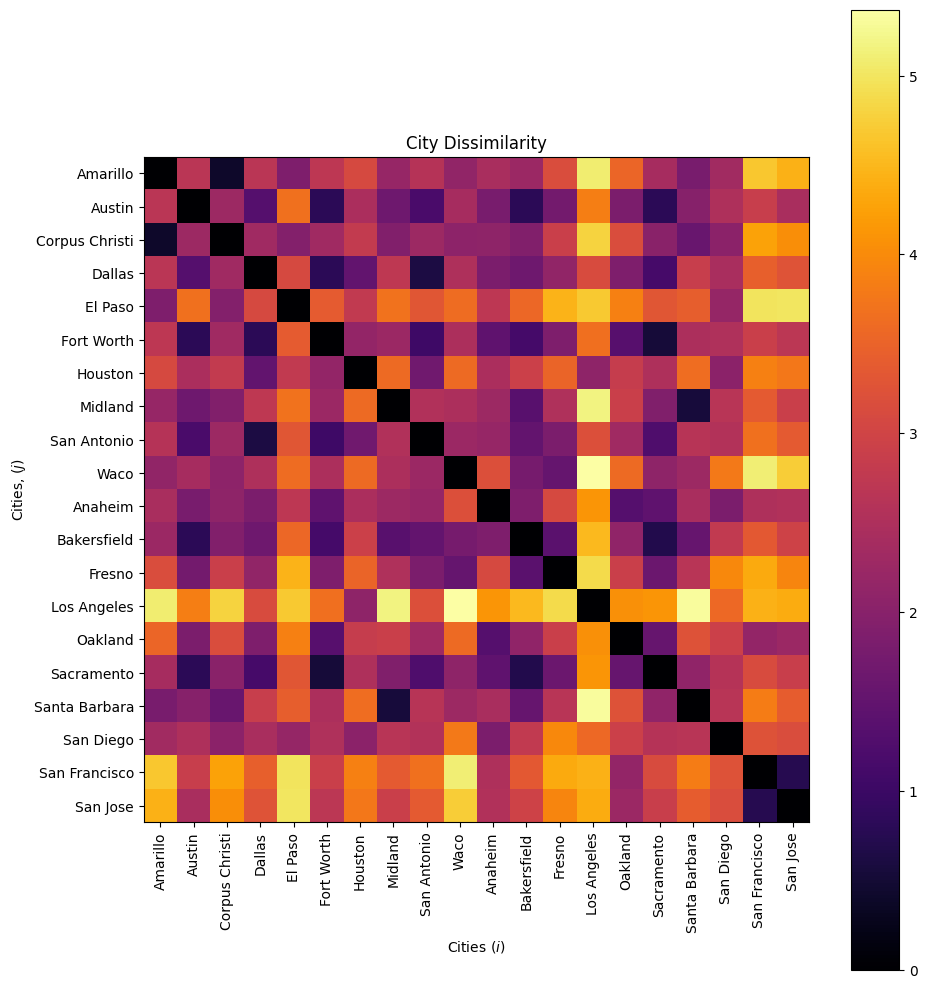

In [8]:
cities = df['Cities'].to_numpy()                                            # Store city names in np.array

df_2 = df.drop(labels='Cities',axis=1)
X = df_2.to_numpy(dtype=np.double)

D = np.zeros(shape=(np.shape(X)[0],np.shape(X)[0]))                         # Pre-allocate D with 20x20 zeros matrix

for i in range(len(D)):                                                     # Span rows
    for j in range(len(D)):                                                 # Span columns
        if i==j:                                                            # Distance of event to itself is null
            continue
        else:
            D[i,j] = np.sqrt((X[j,0]-X[i,0])**2+(X[j,1]-X[i,1])**2+\
                             (X[j,2]-X[i,2])**2+(X[j,3]-X[i,3])**2)         # Euclidean distance

print('First row of D is:\n',D[0,:])
print('First column of D is:\n',D[:,0])
plt.imshow(D,cmap = plt.cm.inferno)
plt.title('City Dissimilarity'); plt.xlabel('Cities ($i$)'); plt.ylabel('Cities, ($j$)');
plt.xticks(np.linspace(0,19,20),df['Cities'],rotation=90);
plt.yticks(np.linspace(0,19,20),df['Cities'],rotation=0); plt.colorbar()
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.3, top=2.0, wspace=0.5, hspace=0.3)

In [9]:
n_components = 2                                                                 # MDS projection dimensionality

embedding = MDS(n_components=2,random_state=20348, dissimilarity='precomputed')  # dissimilarity parameter shows D is already known
nm_scores = embedding.fit_transform(D)

print('MDS projected coordinates matrix (nm_matrix) has dimensions: ', np.shape(nm_scores))

MDS projected coordinates matrix (nm_matrix) has dimensions:  (20, 2)


/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


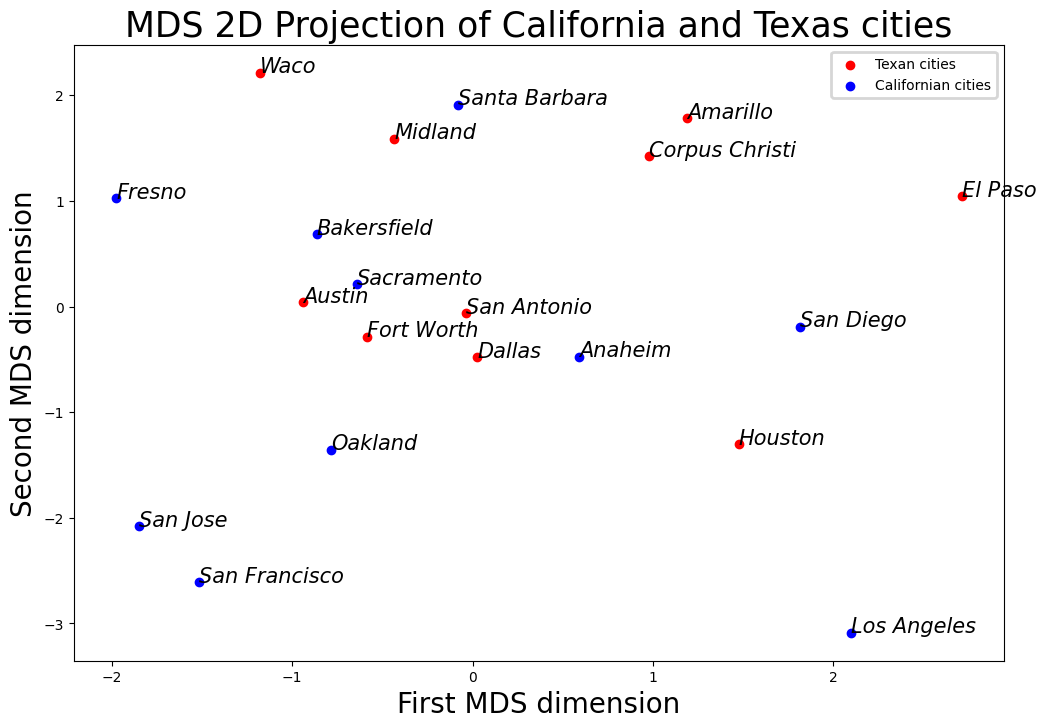

In [10]:
nm_x_proj = nm_scores[:,0]
nm_y_proj = nm_scores[:,1]

plt.figure(figsize=(12,8))
plt.scatter(nm_x_proj[0:10],nm_y_proj[0:10], color='red', label='Texan cities')
plt.scatter(nm_x_proj[10:20],nm_y_proj[10:20], color='blue', label='Californian cities')

for i, txt in enumerate(cities):
    plt.annotate(txt, (nm_x_proj[i], nm_y_proj[i]), size=15, style='italic')

plt.title('MDS 2D Projection of California and Texas cities',size=25)
plt.xlabel('First MDS dimension',size=20)
plt.ylabel('Second MDS dimension',size=20)
legend = plt.legend(); legend.get_frame().set_linewidth(2)
plt.show()